In [1]:
import os
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from matplotlib.colors import LogNorm
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_fscore_support, precision_score, recall_score, f1_score, RocCurveDisplay
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
BASE = "https://data.cityofchicago.org/resource/ijzp-q8t2.json"

COLUMNS = [
    "date",
    "district",
    "primary_type",
    "arrest",
    "domestic"
]

SELECT_COLS = ",".join(COLUMNS)

START_DATE = "2015-01-01T00:00:00"
END_DATE   = "2025-12-31T23:59:59"

In [3]:
def fetch_chicago_crime(base_url, select_cols, start_date, end_date, batch_size=50000, max_rows=None):
    all_rows = []
    offset = 0

    while True:
        params = {
            "$select": select_cols,
            "$where": f"date >= '{start_date}' AND date <= '{end_date}'",
            "$limit": batch_size,
            "$offset": offset,
            "$order": "date ASC"
        }

        r = requests.get(base_url, params=params, timeout=60)
        r.raise_for_status()
        batch = r.json()

        if not batch:
            print(f"Finished. Total rows fetched: {offset}")
            break

        all_rows.extend(batch)
        offset += len(batch)

        print(f"Fetched {offset} rows...")

        if max_rows is not None and offset >= max_rows:
            print(f"Stopped early at {offset} rows (max_rows reached).")
            break

    df = pd.DataFrame(all_rows)
    return df

In [4]:
### IF NO LOCAL DATA IN ../data/ then uncomment code below
# df_full = fetch_chicago_crime(
#     base_url=BASE,
#     select_cols=SELECT_COLS,
#     start_date=START_DATE,
#     end_date=END_DATE,
#     batch_size=50000,
#     max_rows=None
# )

# df_full.to_parquet("../data/chicago_crime_2015_2025.parquet", index=False)

In [5]:
FILE = "../data/chicago_crime_2015_2025.parquet"

if os.path.exists(FILE):
    print("Loading local dataset...")
    df_full = pd.read_parquet(FILE)
    print("Local data was loaded successful.")
else:
    print("No such file,")
    
    df_full = fetch_chicago_crime(
        base_url=BASE,
        select_cols=SELECT_COLS,
        start_date=START_DATE,
        end_date=END_DATE,
        batch_size=50000,
        max_rows=None
    )
    
    df_full.to_parquet(FILE, index=False)

Loading local dataset...
Local data was loaded successful.


In [6]:
df = df_full.copy()

df["date"] = pd.to_datetime(df["date"], errors="coerce")

df["district"] = pd.to_numeric(df["district"], errors="coerce")

def to_binary(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    if x in ["true", "t", "1", "yes"]:
        return 1
    if x in ["false", "f", "0", "no"]:
        return 0
    return np.nan

df["arrest"] = df["arrest"].apply(to_binary)
df["domestic"] = df["domestic"].apply(to_binary)

df["primary_type"] = df["primary_type"].astype(str).str.strip().str.upper()

df = df.dropna(subset=["date", "district", "primary_type"])

df["district"] = df["district"].astype(int)

print(df.shape)
df.head()

(2756365, 5)


,date,district,primary_type,arrest,domestic
0,2015-01-01,22,DECEPTIVE PRACTICE,0,1
1,2015-01-01,1,DECEPTIVE PRACTICE,0,0
2,2015-01-01,15,OFFENSE INVOLVING CHILDREN,0,1
3,2015-01-01,25,DECEPTIVE PRACTICE,0,0
4,2015-01-01,5,DECEPTIVE PRACTICE,0,0


In [7]:
# Prepare for robustness and cross-validation
incident = pd.read_csv(r"../data/NIBRS_incident.csv")
agencies = pd.read_csv(r"../data/agencies.csv")
offense = pd.read_csv(r"../data/NIBRS_OFFENSE.csv")
offense_type = pd.read_csv(r"../data/NIBRS_OFFENSE_TYPE.csv")

In [8]:
# combine csv
# first incident and offense 
inc_off = incident.merge(
    offense[['incident_id', 'offense_id', 'offense_code']],
    on='incident_id',
    how='left'
)

In [9]:
# then offense_type offense_code
inc_off = inc_off.merge(
    offense_type[['offense_code', 'offense_name', 'crime_against', 'offense_category_name', 'offense_group']],
    on='offense_code',
    how='left'
)

In [10]:
# then agencies
nibrs_long = inc_off.merge(
    agencies[['agency_id', 'ori', 'ucr_agency_name', 'pub_agency_name', 'county_name', 'msa_name', 'population', 'state_name']],
    on='agency_id',
    how='left'
)

In [11]:
# generate stander agency_name
agencies_use = agencies.copy()

agencies_use['agency_name'] = agencies_use['pub_agency_name'].fillna(agencies_use['ucr_agency_name'])

nibrs_long = inc_off.merge(
    agencies_use[['agency_id', 'ori', 'agency_name', 'county_name', 'msa_name', 'population', 'state_name']],
    on='agency_id',
    how='left'
)

In [12]:
check_cols = ['agency_id', 'ori', 'ucr_agency_name', 'pub_agency_name', 'county_name', 'msa_name', 'population', 'state_name']
print([c for c in check_cols if c in agencies.columns])

['agency_id', 'ori', 'ucr_agency_name', 'pub_agency_name', 'county_name', 'msa_name', 'population', 'state_name']


In [13]:
agencies_use = agencies.copy()
agencies_use['agency_name'] = agencies_use['pub_agency_name'].fillna(agencies_use['ucr_agency_name'])

nibrs_long = inc_off.merge(
    agencies_use[['agency_id', 'ori', 'agency_name', 'county_name', 'msa_name', 'population', 'state_name']],
    on='agency_id',
    how='left'
)

print(nibrs_long.shape)
print(nibrs_long[['incident_id', 'agency_id', 'agency_name', 'county_name', 'incident_date', 'offense_code']].head())

(434172, 27)
   incident_id  agency_id agency_name county_name incident_date offense_code
0    187030674       2319     Alachua     ALACHUA    2024-01-01          11A
1    185188123       2319     Alachua     ALACHUA    2024-01-01          13B
2    187029473       2319     Alachua     ALACHUA    2024-01-01          13A
3    187029473       2319     Alachua     ALACHUA    2024-01-01          520
4    187029473       2319     Alachua     ALACHUA    2024-01-01          100


In [14]:
inc_off['agency_id'] = pd.to_numeric(inc_off['agency_id'], errors='coerce')
agencies_use['agency_id'] = pd.to_numeric(agencies_use['agency_id'], errors='coerce')

In [15]:
nibrs_long.columns

Index(['data_year', 'agency_id', 'incident_id', 'nibrs_month_id',
       'cargo_theft_flag', 'submission_date', 'incident_date',
       'report_date_flag', 'incident_hour', 'cleared_except_id',
       'cleared_except_date', 'incident_status', 'data_home', 'orig_format',
       'did', 'offense_id', 'offense_code', 'offense_name', 'crime_against',
       'offense_category_name', 'offense_group', 'ori', 'agency_name',
       'county_name', 'msa_name', 'population', 'state_name'],
      dtype='object')

In [16]:
def map_broad_category(row):
    cat = str(row['offense_category_name']).lower()
    against = str(row['crime_against']).lower()
    name = str(row['offense_name']).lower()

    # violent
    if (
        'homicide' in cat or
        'assault' in cat or
        'kidnapping' in cat or
        'sex offenses' in cat or
        'human trafficking' in cat or
        against == 'person'
    ):
        return 'violent'

    # property
    elif (
        'robbery' in cat or
        'burglary' in cat or
        'larceny' in cat or
        'motor vehicle theft' in cat or
        'arson' in cat or
        'fraud' in cat or
        'embezzlement' in cat or
        'stolen property' in cat or
        'destruction/damage/vandalism' in cat or
        against == 'property'
    ):
        return 'property'

    # drug
    elif (
        'drug' in cat or
        'narcotic' in cat or
        'drug/narcotic' in name
    ):
        return 'drug'

    # public order
    elif (
        'weapon law' in cat or
        'disorderly conduct' in cat or
        'trespass' in cat or
        'prostitution' in cat or
        'gambling' in cat or
        'pornography' in cat or
        against == 'society'
    ):
        return 'public_order'

    else:
        return 'other'

In [17]:
nibrs_long['broad_cat'] = nibrs_long.apply(map_broad_category, axis=1)

In [18]:
print(nibrs_long['broad_cat'].value_counts(dropna=False))
print(nibrs_long[['offense_name', 'offense_category_name', 'crime_against', 'broad_cat']].head(20))

broad_cat
property        245195
violent         121220
drug             56040
public_order     11717
Name: count, dtype: int64
                                   offense_name  \
0                                          Rape   
1                                Simple Assault   
2                            Aggravated Assault   
3                         Weapon Law Violations   
4                          Kidnapping/Abduction   
5                  Burglary/Breaking & Entering   
6      Destruction/Damage/Vandalism of Property   
7                                Simple Assault   
8                      Drug/Narcotic Violations   
9                     Drug Equipment Violations   
10                               Simple Assault   
11                           Aggravated Assault   
12  Theft of Motor Vehicle Parts or Accessories   
13                           Aggravated Assault   
14                          Motor Vehicle Theft   
15                 Burglary/Breaking & Entering   
16   

In [19]:
nibrs_long['incident_date'] = pd.to_datetime(nibrs_long['incident_date'], errors='coerce')

nibrs_long['week_start'] = (
    nibrs_long['incident_date']
    - pd.to_timedelta(nibrs_long['incident_date'].dt.weekday, unit='D')
).dt.normalize()

In [20]:
weekly_incident = (
    nibrs_long.groupby(['agency_id', 'week_start'])
    .agg(total_crimes=('incident_id', 'nunique'))
    .reset_index()
)

In [21]:
# weekly_cat
weekly_cat = (
    nibrs_long.groupby(['agency_id', 'week_start', 'broad_cat'])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print(weekly_cat.shape)
print(weekly_cat.head())
print(weekly_cat.columns)

(6795, 6)
broad_cat  agency_id week_start  drug  property  public_order  violent
0               2319 2024-01-01     9        33             1       19
1               2319 2024-01-08     8        41             2       19
2               2319 2024-01-15     6        20             3       21
3               2319 2024-01-22     4        32             3       17
4               2319 2024-01-29     6        41             1       28
Index(['agency_id', 'week_start', 'drug', 'property', 'public_order',
       'violent'],
      dtype='object', name='broad_cat')


In [22]:
# Cambine weekly_incident and weekly_cat 
nibrs_weekly = weekly_incident.merge(
    weekly_cat,
    on=['agency_id', 'week_start'],
    how='left'
)

print(nibrs_weekly.shape)
print(nibrs_weekly.head())

(6795, 7)
   agency_id week_start  total_crimes  drug  property  public_order  violent
0       2319 2024-01-01            55     9        33             1       19
1       2319 2024-01-08            62     8        41             2       19
2       2319 2024-01-15            45     6        20             3       21
3       2319 2024-01-22            52     4        32             3       17
4       2319 2024-01-29            72     6        41             1       28


In [23]:
# add agency 
agency_meta = (
    nibrs_long[['agency_id', 'agency_name', 'county_name', 'msa_name', 'population', 'state_name']]
    .drop_duplicates(subset=['agency_id'])
    .copy()
)

nibrs_weekly = nibrs_weekly.merge(
    agency_meta,
    on='agency_id',
    how='left'
)

print(nibrs_weekly.shape)
print(nibrs_weekly.head())

(6795, 12)
   agency_id week_start  total_crimes  drug  property  public_order  violent  \
0       2319 2024-01-01            55     9        33             1       19   
1       2319 2024-01-08            62     8        41             2       19   
2       2319 2024-01-15            45     6        20             3       21   
3       2319 2024-01-22            52     4        32             3       17   
4       2319 2024-01-29            72     6        41             1       28   

  agency_name county_name         msa_name  population state_name  
0     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
1     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
2     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
3     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
4     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  


In [24]:
# agency × week
all_agencies = nibrs_weekly['agency_id'].dropna().unique()
all_weeks = pd.date_range(
    start=nibrs_weekly['week_start'].min(),
    end=nibrs_weekly['week_start'].max(),
    freq='W-MON'
)

full_index = pd.MultiIndex.from_product(
    [all_agencies, all_weeks],
    names=['agency_id', 'week_start']
)

nibrs_weekly = (
    nibrs_weekly
    .set_index(['agency_id', 'week_start'])
    .reindex(full_index)
    .reset_index()
)

print(nibrs_weekly.shape)
print(nibrs_weekly.head())

(8427, 12)
   agency_id week_start  total_crimes  drug  property  public_order  violent  \
0       2319 2024-01-01          55.0   9.0      33.0           1.0     19.0   
1       2319 2024-01-08          62.0   8.0      41.0           2.0     19.0   
2       2319 2024-01-15          45.0   6.0      20.0           3.0     21.0   
3       2319 2024-01-22          52.0   4.0      32.0           3.0     17.0   
4       2319 2024-01-29          72.0   6.0      41.0           1.0     28.0   

  agency_name county_name         msa_name  population state_name  
0     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
1     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
2     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
3     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  
4     Alachua     ALACHUA  Gainesville, FL    128511.0    Florida  


In [25]:
# change NaN to 0
fill_zero_cols = ['total_crimes', 'violent', 'property', 'drug', 'public_order', 'other']
fill_zero_cols = [c for c in fill_zero_cols if c in nibrs_weekly.columns]

for c in fill_zero_cols:
    nibrs_weekly[c] = nibrs_weekly[c].fillna(0)

In [26]:
meta_cols = ['agency_name', 'county_name', 'msa_name', 'population', 'state_name']

nibrs_weekly = nibrs_weekly.sort_values(['agency_id', 'week_start']).copy()

for c in meta_cols:
    if c in nibrs_weekly.columns:
        nibrs_weekly[c] = nibrs_weekly.groupby('agency_id')[c].transform(lambda s: s.ffill().bfill())

C:\Users\13398\AppData\Local\Temp\ipykernel_26352\175090317.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nibrs_weekly[c] = nibrs_weekly.groupby('agency_id')[c].transform(lambda s: s.ffill().bfill())


In [27]:
for c in ['violent', 'property', 'drug', 'public_order', 'other']:
    if c in nibrs_weekly.columns:
        nibrs_weekly[f'ratio_{c}'] = (
            nibrs_weekly[c] / nibrs_weekly['total_crimes'].replace(0, np.nan)
        )

In [28]:
nibrs_weekly = nibrs_weekly.sort_values(['agency_id', 'week_start']).copy()

nibrs_weekly['lag_1w'] = nibrs_weekly.groupby('agency_id')['total_crimes'].shift(1)
nibrs_weekly['lag_2w'] = nibrs_weekly.groupby('agency_id')['total_crimes'].shift(2)

nibrs_weekly['rolling_mean_4w'] = (
    nibrs_weekly.groupby('agency_id')['total_crimes']
    .shift(1)
    .rolling(window=4, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

nibrs_weekly['week_of_year'] = nibrs_weekly['week_start'].dt.isocalendar().week.astype(int)

In [29]:
# for check
agency_total = (
    nibrs_weekly.groupby('agency_id')['total_crimes']
    .sum()
    .reset_index(name='year_total_crimes')
    .sort_values('year_total_crimes', ascending=False)
)

print(agency_total.head(20))
print(agency_total['year_total_crimes'].describe())

     agency_id  year_total_crimes
52        2615            56132.0
27        2539            49598.0
32        2545            24622.0
67        2791            19840.0
68        2793            18921.0
78        2920            11514.0
1         2320             7957.0
23        2513             7573.0
85        2998             7393.0
113       3195             6897.0
147       3319             6674.0
105       3134             6302.0
86        2999             5679.0
65        2765             5605.0
20        2500             5234.0
10        2400             4951.0
5         2388             4700.0
102       3129             4523.0
48        2586             4522.0
88        3013             4305.0
count      159.000000
mean      2450.742138
std       6619.955784
min          1.000000
25%        177.000000
50%        577.000000
75%       2107.500000
max      56132.000000
Name: year_total_crimes, dtype: float64


In [30]:
# top 25 agency
top_agencies = agency_total.head(25)['agency_id']
nibrs_weekly_sub = nibrs_weekly[nibrs_weekly['agency_id'].isin(top_agencies)].copy()

print(nibrs_weekly_sub['agency_id'].nunique())
print(nibrs_weekly_sub.shape)

25
(1325, 20)


In [31]:
nibrs_weekly_sub["week_of_year"] = nibrs_weekly_sub["week_start"].dt.isocalendar().week.astype(int)
nibrs_weekly_sub["month"] = nibrs_weekly_sub["week_start"].dt.month.astype(int)
nibrs_weekly_sub["year"] = nibrs_weekly_sub["week_start"].dt.year.astype(int)

In [32]:
nibrs_weekly_sub[["week_start", "week_of_year", "month", "year"]].head()

,week_start,week_of_year,month,year
53,2024-01-01,1,1,2024
54,2024-01-08,2,1,2024
55,2024-01-15,3,1,2024
56,2024-01-22,4,1,2024
57,2024-01-29,5,1,2024


In [33]:
# define hotspot
hotspot_ratio = 3 / 22

In [34]:
# define generic features
generic_features = [
    "total_crimes",
    "lag_1w",
    "lag_2w",
    "rolling_mean_4w",
    "week_of_year",
    "ratio_violent",
    "ratio_property",
    "ratio_drug",
    "ratio_public_order"
]

In [35]:
# define NIBRS' hotspot
# Define weekly hotspot threshold based on Chicago prevalence
weekly_thresholds = (
    nibrs_weekly_sub.groupby("week_start")["total_crimes"]
    .quantile(1 - hotspot_ratio)
    .rename("weekly_hotspot_threshold")
    .reset_index()
)

nibrs_weekly_sub = nibrs_weekly_sub.merge(
    weekly_thresholds,
    on="week_start",
    how="left"
)

nibrs_weekly_sub["is_hotspot"] = (
    nibrs_weekly_sub["total_crimes"] >= nibrs_weekly_sub["weekly_hotspot_threshold"]
).astype(int)

In [36]:
# Create next-week prediction target
nibrs_weekly_sub = nibrs_weekly_sub.sort_values(["agency_id", "week_start"]).copy()

nibrs_weekly_sub["target_next_week"] = (
    nibrs_weekly_sub.groupby("agency_id")["is_hotspot"].shift(-1)
)

In [37]:
# delete NaN
nibrs_eval = nibrs_weekly_sub.dropna(subset=["target_next_week"]).copy()
nibrs_eval["target_next_week"] = nibrs_eval["target_next_week"].astype(int)

In [38]:
# clean
nibrs_eval_clean = nibrs_eval.dropna(subset=generic_features + ["target_next_week"]).copy()
nibrs_eval_clean["target_next_week"] = nibrs_eval_clean["target_next_week"].astype(int)

print("NIBRS clean rows:", len(nibrs_eval_clean))
print("NIBRS positive rate:", nibrs_eval_clean["target_next_week"].mean())

NIBRS clean rows: 1212
NIBRS positive rate: 0.16501650165016502


In [39]:
# NIBRS X/Y
X_nibrs = nibrs_eval_clean[generic_features].copy()
y_nibrs = nibrs_eval_clean["target_next_week"].astype(int)

print(X_nibrs.shape, y_nibrs.shape)

(1212, 9) (1212,)


In [40]:
def map_chicago_broad_category(primary_type):
    x = str(primary_type).strip().lower()
    
    if x in [
        "homicide",
        "assault",
        "battery",
        "robbery",
        "criminal sexual assault",
        "crim sexual assault",
        "sex offense",
        "kidnapping",
        "human trafficking"
    ]:
        return "violent"

    elif x in [
        "theft", "burglary", "motor vehicle theft",
        "criminal damage", "deceptive practice",
        "arson", "criminal trespass", "possession of stolen property"
    ]:
        return "property"

    elif x in [
        "narcotics", "other narcotic violation"
    ]:
        return "drug"

    elif x in [
        "weapons violation", "public peace violation",
        "interference with public officer", "obscenity",
        "gambling", "liquor law violation", "other offense",
        "offense involving children"
    ]:
        return "public_order"

    else:
        return "other"

In [41]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["hour"] = df["date"].dt.hour
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)

df["week_start"] = df["date"].dt.to_period("W").apply(lambda r: r.start_time)

In [42]:
df["broad_cat"] = df["primary_type"].apply(map_chicago_broad_category)

In [43]:
print(df["broad_cat"].value_counts())

df[["primary_type", "broad_cat"]]\
.drop_duplicates()\
.sort_values(["broad_cat","primary_type"])\
.head(30)

broad_cat
property        1461490
violent          868346
public_order     299519
drug             114220
other             12790
Name: count, dtype: int64


,primary_type,broad_cat
478,NARCOTICS,drug
27842,OTHER NARCOTIC VIOLATION,drug
23078,CONCEALED CARRY LICENSE VIOLATION,other
1411,INTIMIDATION,other
126984,NON-CRIMINAL,other
1375,PROSTITUTION,other
3287,PUBLIC INDECENCY,other
1524385,RITUALISM,other
738,STALKING,other
1955,ARSON,property


In [44]:
# Count crimes by broad category per district-week
weekly_cat = (
    df.groupby(["district", "week_start", "broad_cat"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

weekly_cat.head()

broad_cat,district,week_start,drug,other,property,public_order,violent
0,1,2014-12-29,0,0,60,6,28
1,1,2015-01-05,7,2,116,9,36
2,1,2015-01-12,1,1,163,12,33
3,1,2015-01-19,2,2,185,10,48
4,1,2015-01-26,2,0,136,21,48


In [45]:
# total crimes
broad_cols = ["violent", "property", "drug", "public_order", "other"]

weekly_cat["total_crimes"] = weekly_cat[broad_cols].sum(axis=1)

weekly_cat.head()

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes
0,1,2014-12-29,0,0,60,6,28,94
1,1,2015-01-05,7,2,116,9,36,170
2,1,2015-01-12,1,1,163,12,33,210
3,1,2015-01-19,2,2,185,10,48,247
4,1,2015-01-26,2,0,136,21,48,207


In [46]:
for col in broad_cols:
    weekly_cat[f"ratio_{col}"] = weekly_cat[col] / weekly_cat["total_crimes"].replace(0, 1)

weekly_cat.head()

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes,ratio_violent,ratio_property,ratio_drug,ratio_public_order,ratio_other
0,1,2014-12-29,0,0,60,6,28,94,0.297872,0.638298,0.000000,0.063830,0.000000
1,1,2015-01-05,7,2,116,9,36,170,0.211765,0.682353,0.041176,0.052941,0.011765
2,1,2015-01-12,1,1,163,12,33,210,0.157143,0.776190,0.004762,0.057143,0.004762
3,1,2015-01-19,2,2,185,10,48,247,0.194332,0.748988,0.008097,0.040486,0.008097
4,1,2015-01-26,2,0,136,21,48,207,0.231884,0.657005,0.009662,0.101449,0.000000


In [47]:
weekly_cat["week_of_year"] = weekly_cat["week_start"].dt.isocalendar().week.astype(int)
weekly_cat["month"] = weekly_cat["week_start"].dt.month.astype(int)
weekly_cat["year"] = weekly_cat["week_start"].dt.year.astype(int)

weekly_cat.head()

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes,ratio_violent,ratio_property,ratio_drug,ratio_public_order,ratio_other,week_of_year,month,year
0,1,2014-12-29,0,0,60,6,28,94,0.297872,0.638298,0.000000,0.063830,0.000000,1,12,2014
1,1,2015-01-05,7,2,116,9,36,170,0.211765,0.682353,0.041176,0.052941,0.011765,2,1,2015
2,1,2015-01-12,1,1,163,12,33,210,0.157143,0.776190,0.004762,0.057143,0.004762,3,1,2015
3,1,2015-01-19,2,2,185,10,48,247,0.194332,0.748988,0.008097,0.040486,0.008097,4,1,2015
4,1,2015-01-26,2,0,136,21,48,207,0.231884,0.657005,0.009662,0.101449,0.000000,5,1,2015


In [48]:
weekly_cat = weekly_cat.sort_values(["district", "week_start"]).copy()

weekly_cat["lag_1w"] = weekly_cat.groupby("district")["total_crimes"].shift(1)
weekly_cat["lag_2w"] = weekly_cat.groupby("district")["total_crimes"].shift(2)

weekly_cat["rolling_mean_4w"] = (
    weekly_cat.groupby("district")["total_crimes"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
)

weekly_cat.head(10)

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes,ratio_violent,ratio_property,ratio_drug,ratio_public_order,ratio_other,week_of_year,month,year,lag_1w,lag_2w,rolling_mean_4w
0,1,2014-12-29,0,0,60,6,28,94,0.297872,0.638298,0.000000,0.063830,0.000000,1,12,2014,NaN,NaN,NaN
1,1,2015-01-05,7,2,116,9,36,170,0.211765,0.682353,0.041176,0.052941,0.011765,2,1,2015,94.0,NaN,94.00
2,1,2015-01-12,1,1,163,12,33,210,0.157143,0.776190,0.004762,0.057143,0.004762,3,1,2015,170.0,94.0,132.00
3,1,2015-01-19,2,2,185,10,48,247,0.194332,0.748988,0.008097,0.040486,0.008097,4,1,2015,210.0,170.0,158.00
4,1,2015-01-26,2,0,136,21,48,207,0.231884,0.657005,0.009662,0.101449,0.000000,5,1,2015,247.0,210.0,180.25
5,1,2015-02-02,11,2,113,11,37,174,0.212644,0.649425,0.063218,0.063218,0.011494,6,2,2015,207.0,247.0,208.50
6,1,2015-02-09,5,2,125,8,33,173,0.190751,0.722543,0.028902,0.046243,0.011561,7,2,2015,174.0,207.0,209.50
7,1,2015-02-16,6,1,113,10,32,162,0.197531,0.697531,0.037037,0.061728,0.006173,8,2,2015,173.0,174.0,200.25
8,1,2015-02-23,1,1,126,9,30,167,0.179641,0.754491,0.005988,0.053892,0.005988,9,2,2015,162.0,173.0,179.00
9,1,2015-03-02,3,0,126,7,41,177,0.231638,0.711864,0.016949,0.039548,0.000000,10,3,2015,167.0,162.0,169.00


In [49]:
# Chicago's hotspot
# ratio
for col in broad_cols:
    weekly_cat[f"ratio_{col}"] = weekly_cat[col] / weekly_cat["total_crimes"].replace(0, 1)

weekly_cat.head()

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes,ratio_violent,ratio_property,ratio_drug,ratio_public_order,ratio_other,week_of_year,month,year,lag_1w,lag_2w,rolling_mean_4w
0,1,2014-12-29,0,0,60,6,28,94,0.297872,0.638298,0.000000,0.063830,0.000000,1,12,2014,NaN,NaN,NaN
1,1,2015-01-05,7,2,116,9,36,170,0.211765,0.682353,0.041176,0.052941,0.011765,2,1,2015,94.0,NaN,94.00
2,1,2015-01-12,1,1,163,12,33,210,0.157143,0.776190,0.004762,0.057143,0.004762,3,1,2015,170.0,94.0,132.00
3,1,2015-01-19,2,2,185,10,48,247,0.194332,0.748988,0.008097,0.040486,0.008097,4,1,2015,210.0,170.0,158.00
4,1,2015-01-26,2,0,136,21,48,207,0.231884,0.657005,0.009662,0.101449,0.000000,5,1,2015,247.0,210.0,180.25


In [50]:
weekly_cat["week_of_year"] = weekly_cat["week_start"].dt.isocalendar().week.astype(int)
weekly_cat["month"] = weekly_cat["week_start"].dt.month.astype(int)
weekly_cat["year"] = weekly_cat["week_start"].dt.year.astype(int)

weekly_cat.head()

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes,ratio_violent,ratio_property,ratio_drug,ratio_public_order,ratio_other,week_of_year,month,year,lag_1w,lag_2w,rolling_mean_4w
0,1,2014-12-29,0,0,60,6,28,94,0.297872,0.638298,0.000000,0.063830,0.000000,1,12,2014,NaN,NaN,NaN
1,1,2015-01-05,7,2,116,9,36,170,0.211765,0.682353,0.041176,0.052941,0.011765,2,1,2015,94.0,NaN,94.00
2,1,2015-01-12,1,1,163,12,33,210,0.157143,0.776190,0.004762,0.057143,0.004762,3,1,2015,170.0,94.0,132.00
3,1,2015-01-19,2,2,185,10,48,247,0.194332,0.748988,0.008097,0.040486,0.008097,4,1,2015,210.0,170.0,158.00
4,1,2015-01-26,2,0,136,21,48,207,0.231884,0.657005,0.009662,0.101449,0.000000,5,1,2015,247.0,210.0,180.25


In [51]:
# lag / rolling
weekly_cat = weekly_cat.sort_values(["district", "week_start"]).copy()

weekly_cat["lag_1w"] = weekly_cat.groupby("district")["total_crimes"].shift(1)
weekly_cat["lag_2w"] = weekly_cat.groupby("district")["total_crimes"].shift(2)

weekly_cat["rolling_mean_4w"] = (
    weekly_cat.groupby("district")["total_crimes"]
    .transform(lambda s: s.shift(1).rolling(4, min_periods=1).mean())
)

weekly_cat.head(10)

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes,ratio_violent,ratio_property,ratio_drug,ratio_public_order,ratio_other,week_of_year,month,year,lag_1w,lag_2w,rolling_mean_4w
0,1,2014-12-29,0,0,60,6,28,94,0.297872,0.638298,0.000000,0.063830,0.000000,1,12,2014,NaN,NaN,NaN
1,1,2015-01-05,7,2,116,9,36,170,0.211765,0.682353,0.041176,0.052941,0.011765,2,1,2015,94.0,NaN,94.00
2,1,2015-01-12,1,1,163,12,33,210,0.157143,0.776190,0.004762,0.057143,0.004762,3,1,2015,170.0,94.0,132.00
3,1,2015-01-19,2,2,185,10,48,247,0.194332,0.748988,0.008097,0.040486,0.008097,4,1,2015,210.0,170.0,158.00
4,1,2015-01-26,2,0,136,21,48,207,0.231884,0.657005,0.009662,0.101449,0.000000,5,1,2015,247.0,210.0,180.25
5,1,2015-02-02,11,2,113,11,37,174,0.212644,0.649425,0.063218,0.063218,0.011494,6,2,2015,207.0,247.0,208.50
6,1,2015-02-09,5,2,125,8,33,173,0.190751,0.722543,0.028902,0.046243,0.011561,7,2,2015,174.0,207.0,209.50
7,1,2015-02-16,6,1,113,10,32,162,0.197531,0.697531,0.037037,0.061728,0.006173,8,2,2015,173.0,174.0,200.25
8,1,2015-02-23,1,1,126,9,30,167,0.179641,0.754491,0.005988,0.053892,0.005988,9,2,2015,162.0,173.0,179.00
9,1,2015-03-02,3,0,126,7,41,177,0.231638,0.711864,0.016949,0.039548,0.000000,10,3,2015,167.0,162.0,169.00


In [52]:
weekly_cat = weekly_cat.dropna(subset=["lag_1w", "lag_2w", "rolling_mean_4w"]).copy()

In [53]:
weekly_cat.head(10)

broad_cat,district,week_start,drug,other,property,public_order,violent,total_crimes,ratio_violent,ratio_property,ratio_drug,ratio_public_order,ratio_other,week_of_year,month,year,lag_1w,lag_2w,rolling_mean_4w
2,1,2015-01-12,1,1,163,12,33,210,0.157143,0.776190,0.004762,0.057143,0.004762,3,1,2015,170.0,94.0,132.00
3,1,2015-01-19,2,2,185,10,48,247,0.194332,0.748988,0.008097,0.040486,0.008097,4,1,2015,210.0,170.0,158.00
4,1,2015-01-26,2,0,136,21,48,207,0.231884,0.657005,0.009662,0.101449,0.000000,5,1,2015,247.0,210.0,180.25
5,1,2015-02-02,11,2,113,11,37,174,0.212644,0.649425,0.063218,0.063218,0.011494,6,2,2015,207.0,247.0,208.50
6,1,2015-02-09,5,2,125,8,33,173,0.190751,0.722543,0.028902,0.046243,0.011561,7,2,2015,174.0,207.0,209.50
7,1,2015-02-16,6,1,113,10,32,162,0.197531,0.697531,0.037037,0.061728,0.006173,8,2,2015,173.0,174.0,200.25
8,1,2015-02-23,1,1,126,9,30,167,0.179641,0.754491,0.005988,0.053892,0.005988,9,2,2015,162.0,173.0,179.00
9,1,2015-03-02,3,0,126,7,41,177,0.231638,0.711864,0.016949,0.039548,0.000000,10,3,2015,167.0,162.0,169.00
10,1,2015-03-09,2,1,159,9,60,231,0.259740,0.688312,0.008658,0.038961,0.004329,11,3,2015,177.0,167.0,169.75
11,1,2015-03-16,2,0,161,10,43,216,0.199074,0.745370,0.009259,0.046296,0.000000,12,3,2015,231.0,177.0,184.25


In [54]:
# Define hotspot as top 3 districts each week
weekly_cat = weekly_cat.sort_values(
    ["week_start", "total_crimes"],
    ascending=[True, False]
).copy()

weekly_cat["weekly_rank"] = (
    weekly_cat.groupby("week_start")["total_crimes"]
    .rank(method="first", ascending=False)
)

weekly_cat["is_hotspot"] = (weekly_cat["weekly_rank"] <= 3).astype(int)

In [55]:
# Create next-week target
weekly_cat = weekly_cat.sort_values(["district", "week_start"]).copy()

weekly_cat["target_next_week"] = (
    weekly_cat.groupby("district")["is_hotspot"].shift(-1)
)

In [56]:
# cleanning
chicago_generic_df = weekly_cat.dropna(
    subset=["lag_1w", "lag_2w", "rolling_mean_4w", "target_next_week"]
).copy()

chicago_generic_df["target_next_week"] = chicago_generic_df["target_next_week"].astype(int)
chicago_generic_df.columns.name = None

In [57]:
# check
print("Chicago generic rows:", len(chicago_generic_df))
print("Chicago generic positive rate:", chicago_generic_df["target_next_week"].mean())
print()

print(chicago_generic_df[[
    "district", "week_start", "total_crimes",
    "lag_1w", "lag_2w", "rolling_mean_4w",
    "weekly_rank", "is_hotspot", "target_next_week"
]].head(10))

Chicago generic rows: 12682
Chicago generic positive rate: 0.13530988803027913

    district week_start  total_crimes  lag_1w  lag_2w  rolling_mean_4w  \
2          1 2015-01-12           210   170.0    94.0           132.00   
3          1 2015-01-19           247   210.0   170.0           158.00   
4          1 2015-01-26           207   247.0   210.0           180.25   
5          1 2015-02-02           174   207.0   247.0           208.50   
6          1 2015-02-09           173   174.0   207.0           209.50   
7          1 2015-02-16           162   173.0   174.0           200.25   
8          1 2015-02-23           167   162.0   173.0           179.00   
9          1 2015-03-02           177   167.0   162.0           169.00   
10         1 2015-03-09           231   177.0   167.0           169.75   
11         1 2015-03-16           216   231.0   177.0           184.25   

    weekly_rank  is_hotspot  target_next_week  
2          10.0           0                 0  
3        

In [58]:
train_generic = chicago_generic_df[chicago_generic_df["year"] <= 2023].copy()
val_generic   = chicago_generic_df[chicago_generic_df["year"] == 2024].copy()
test_generic  = chicago_generic_df[chicago_generic_df["year"] == 2025].copy()

print("train:", train_generic.shape)
print("val:", val_generic.shape)
print("test:", test_generic.shape)

print("train positive rate:", train_generic["target_next_week"].mean())
print("val positive rate:", val_generic["target_next_week"].mean())
print("test positive rate:", test_generic["target_next_week"].mean())

train: (10377, 22)
val: (1176, 22)
test: (1129, 22)
train positive rate: 0.13529921942758022
val positive rate: 0.13520408163265307
test positive rate: 0.1355181576616475


In [59]:
X_train_generic = train_generic[generic_features].copy()
y_train_generic = train_generic["target_next_week"].astype(int)

X_val_generic = val_generic[generic_features].copy()
y_val_generic = val_generic["target_next_week"].astype(int)

X_test_generic = test_generic[generic_features].copy()
y_test_generic = test_generic["target_next_week"].astype(int)

print(X_train_generic.shape, y_train_generic.shape)
print(X_val_generic.shape, y_val_generic.shape)
print(X_test_generic.shape, y_test_generic.shape)

(10377, 9) (10377,)
(1176, 9) (1176,)
(1129, 9) (1129,)


In [60]:
# Model 1: Logistic Regression (baseline)
lr_generic = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

lr_generic.fit(X_train_generic, y_train_generic)

,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [61]:
# LR validation threshold tuning
val_prob_lr = lr_generic.predict_proba(X_val_generic)[:, 1]

print("Chicago Generic Validation AUC (LR):", roc_auc_score(y_val_generic, val_prob_lr))

thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

rows_lr = []
for th in thresholds:
    pred = (val_prob_lr >= th).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_val_generic, pred, average="binary", zero_division=0
    )
    rows_lr.append({
        "threshold": th,
        "precision": p,
        "recall": r,
        "f1": f1
    })

threshold_df_lr = pd.DataFrame(rows_lr)
threshold_df_lr.sort_values("f1", ascending=False)

Chicago Generic Validation AUC (LR): 0.9178617589036691


,threshold,precision,recall,f1
8,0.60,0.443686,0.817610,0.575221
7,0.55,0.399399,0.836478,0.540650
6,0.50,0.363636,0.855346,0.510319
5,0.45,0.336493,0.893082,0.488812
4,0.40,0.319742,0.937107,0.476800
3,0.35,0.307692,0.955975,0.465544
2,0.30,0.288136,0.962264,0.443478
1,0.25,0.273852,0.974843,0.427586
0,0.20,0.259868,0.993711,0.411995


In [62]:
best_threshold_lr = 0.55

In [63]:
# LR on Chicago test
test_prob_lr = lr_generic.predict_proba(X_test_generic)[:, 1]
test_pred_lr = (test_prob_lr >= best_threshold_lr).astype(int)

print("=== Chicago Generic Test (Logistic Regression) ===")
print(classification_report(y_test_generic, test_pred_lr, digits=4))
print("Chicago Generic Test AUC (LR):", roc_auc_score(y_test_generic, test_prob_lr))

=== Chicago Generic Test (Logistic Regression) ===
              precision    recall  f1-score   support

           0     0.9408    0.8955    0.9176       976
           1     0.4900    0.6405    0.5552       153

    accuracy                         0.8609      1129
   macro avg     0.7154    0.7680    0.7364      1129
weighted avg     0.8797    0.8609    0.8685      1129

Chicago Generic Test AUC (LR): 0.9011906675238402


In [64]:
# LR external validation on NIBRS
nibrs_prob_lr = lr_generic.predict_proba(X_nibrs)[:, 1]
nibrs_pred_lr = (nibrs_prob_lr >= best_threshold_lr).astype(int)

print("=== External Validation on NIBRS (Logistic Regression) ===")
print(classification_report(y_nibrs, nibrs_pred_lr, digits=4))
print("NIBRS External AUC (LR):", roc_auc_score(y_nibrs, nibrs_prob_lr))

=== External Validation on NIBRS (Logistic Regression) ===
              precision    recall  f1-score   support

           0     0.9979    0.9526    0.9747      1012
           1     0.8049    0.9900    0.8879       200

    accuracy                         0.9587      1212
   macro avg     0.9014    0.9713    0.9313      1212
weighted avg     0.9661    0.9587    0.9604      1212

NIBRS External AUC (LR): 0.9940464426877471


In [65]:
# Model 2: Random Forest
rf_generic = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_generic.fit(X_train_generic, y_train_generic)

,n_estimators,300
,criterion,'gini'
,max_depth,8
,min_samples_split,20
,min_samples_leaf,8
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [66]:
# RF validation threshold tuning
val_prob_rf = rf_generic.predict_proba(X_val_generic)[:, 1]

print("Chicago Generic Validation AUC (RF):", roc_auc_score(y_val_generic, val_prob_rf))

rows_rf = []
for th in thresholds:
    pred = (val_prob_rf >= th).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_val_generic, pred, average="binary", zero_division=0
    )
    rows_rf.append({
        "threshold": th,
        "precision": p,
        "recall": r,
        "f1": f1
    })

threshold_df_rf = pd.DataFrame(rows_rf)
threshold_df_rf.sort_values("f1", ascending=False)

Chicago Generic Validation AUC (RF): 0.9115106089559255


,threshold,precision,recall,f1
8,0.60,0.475096,0.779874,0.590476
7,0.55,0.424837,0.817610,0.559140
6,0.50,0.380682,0.842767,0.524462
5,0.45,0.349614,0.855346,0.496350
4,0.40,0.329466,0.893082,0.481356
3,0.35,0.313596,0.899371,0.465041
2,0.30,0.296524,0.911950,0.447531
1,0.25,0.278409,0.924528,0.427948
0,0.20,0.267951,0.962264,0.419178


In [67]:
best_threshold_rf = 0.5

In [68]:
# RF on Chicago test
test_prob_rf = rf_generic.predict_proba(X_test_generic)[:, 1]
test_pred_rf = (test_prob_rf >= best_threshold_rf).astype(int)

print("=== Chicago Generic Test (Random Forest) ===")
print(classification_report(y_test_generic, test_pred_rf, digits=4))
print("Chicago Generic Test AUC (RF):", roc_auc_score(y_test_generic, test_prob_rf))

=== Chicago Generic Test (Random Forest) ===
              precision    recall  f1-score   support

           0     0.9461    0.8986    0.9217       976
           1     0.5099    0.6732    0.5803       153

    accuracy                         0.8680      1129
   macro avg     0.7280    0.7859    0.7510      1129
weighted avg     0.8870    0.8680    0.8754      1129

Chicago Generic Test AUC (RF): 0.9056506482374371


In [69]:
# #RF external validation on NIBRS
nibrs_prob_rf = rf_generic.predict_proba(X_nibrs)[:, 1]
nibrs_pred_rf = (nibrs_prob_rf >= best_threshold_rf).astype(int)

print("=== External Validation on NIBRS (Random Forest) ===")
print(classification_report(y_nibrs, nibrs_pred_rf, digits=4))
print("NIBRS External AUC (RF):", roc_auc_score(y_nibrs, nibrs_prob_rf))

=== External Validation on NIBRS (Random Forest) ===
              precision    recall  f1-score   support

           0     0.9969    0.9516    0.9737      1012
           1     0.8008    0.9850    0.8834       200

    accuracy                         0.9571      1212
   macro avg     0.8989    0.9683    0.9286      1212
weighted avg     0.9645    0.9571    0.9588      1212

NIBRS External AUC (RF): 0.9647430830039526


In [70]:
# Model 3: generic GB
gb_generic = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_generic.fit(X_train_generic, y_train_generic)

,loss,'log_loss'
,learning_rate,0.05
,n_estimators,200
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [71]:
# Chicago validation 
val_prob_generic = gb_generic.predict_proba(X_val_generic)[:, 1]

print("Chicago Generic Validation AUC:", roc_auc_score(y_val_generic, val_prob_generic))

Chicago Generic Validation AUC: 0.9184492557342783


In [72]:
# threshold
thresholds = [0.1, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]

rows = []
for th in thresholds:
    pred = (val_prob_generic >= th).astype(int)
    p, r, f1, _ = precision_recall_fscore_support(
        y_val_generic, pred, average="binary", zero_division=0
    )
    rows.append({
        "threshold": th,
        "precision": p,
        "recall": r,
        "f1": f1
    })

import pandas as pd
threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,precision,recall,f1
0,0.10,0.311966,0.918239,0.465710
1,0.20,0.414330,0.836478,0.554167
2,0.25,0.482625,0.786164,0.598086
3,0.30,0.522727,0.723270,0.606860
4,0.35,0.567164,0.716981,0.633333
5,0.40,0.634731,0.666667,0.650307
6,0.45,0.678322,0.610063,0.642384
7,0.50,0.712121,0.591195,0.646048
8,0.55,0.739496,0.553459,0.633094
9,0.60,0.771429,0.509434,0.613636


In [73]:
# test generic model
best_threshold_generic = 0.40

test_prob_generic = gb_generic.predict_proba(X_test_generic)[:, 1]
test_pred_generic = (test_prob_generic >= best_threshold_generic).astype(int)

print("=== Chicago Generic Test ===")
print(classification_report(y_test_generic, test_pred_generic, digits=4))
print("Chicago Generic Test AUC:", roc_auc_score(y_test_generic, test_prob_generic))

=== Chicago Generic Test ===
              precision    recall  f1-score   support

           0     0.9076    0.9867    0.9455       976
           1     0.8088    0.3595    0.4977       153

    accuracy                         0.9017      1129
   macro avg     0.8582    0.6731    0.7216      1129
weighted avg     0.8942    0.9017    0.8848      1129

Chicago Generic Test AUC: 0.9143094396228436


In [74]:
feature_importance_generic = pd.DataFrame({
    "feature": generic_features,
    "importance": gb_generic.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance_generic

,feature,importance
3,rolling_mean_4w,0.568554
0,total_crimes,0.146453
7,ratio_drug,0.103339
4,week_of_year,0.079864
6,ratio_property,0.038928
2,lag_2w,0.020320
1,lag_1w,0.014894
5,ratio_violent,0.014208
8,ratio_public_order,0.013439


In [75]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_robustness_by_agency(
    nibrs_eval_clean,
    y_true,
    y_pred,
    y_prob,
    model_name
):
    agency_perf = (
        nibrs_eval_clean.assign(pred=y_pred, prob=y_prob)
        .groupby("agency_id")
        .apply(lambda g: pd.Series({
            "rows": len(g),
            "positive_rate": g["target_next_week"].mean(),
            "precision": precision_score(g["target_next_week"], g["pred"], zero_division=0),
            "recall": recall_score(g["target_next_week"], g["pred"], zero_division=0),
            "f1": f1_score(g["target_next_week"], g["pred"], zero_division=0),
            "auc": roc_auc_score(g["target_next_week"], g["prob"]) if g["target_next_week"].nunique() > 1 else None
        }))
        .reset_index()
    )

    print(f"=== Agency-level Robustness: {model_name} ===")
    print("\nTop 10 agencies by F1")
    display(agency_perf.sort_values("f1", ascending=False).head(10))

    print("\nBottom 10 agencies by F1")
    display(agency_perf.sort_values("f1", ascending=True).head(10))

    RocCurveDisplay.from_predictions(y_true, y_prob)
    plt.title(f"ROC Curve - NIBRS External Validation ({model_name})")
    plt.show()

    return agency_perf

=== Agency-level Robustness: Logistic Regression ===

Top 10 agencies by F1


C:\Users\13398\AppData\Local\Temp\ipykernel_26352\1802885967.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,agency_id,rows,positive_rate,precision,recall,f1,auc
7,2539,50.0,1.00,1.000000,1.000000,1.000000,NaN
10,2615,50.0,1.00,1.000000,1.000000,1.000000,NaN
8,2545,50.0,0.92,0.936170,0.956522,0.946237,0.815217
12,2791,50.0,0.72,0.720000,1.000000,0.837209,0.472222
13,2793,50.0,0.36,0.367347,1.000000,0.537313,0.720486
4,2477,50.0,0.00,0.000000,0.000000,0.000000,NaN
0,2320,50.0,0.00,0.000000,0.000000,0.000000,NaN
1,2388,50.0,0.00,0.000000,0.000000,0.000000,NaN
2,2400,50.0,0.00,0.000000,0.000000,0.000000,NaN
5,2500,50.0,0.00,0.000000,0.000000,0.000000,NaN



Bottom 10 agencies by F1


,agency_id,rows,positive_rate,precision,recall,f1,auc
0,2320,50.0,0.0,0.0,0.0,0.0,NaN
1,2388,50.0,0.0,0.0,0.0,0.0,NaN
2,2400,50.0,0.0,0.0,0.0,0.0,NaN
3,2421,16.0,0.0,0.0,0.0,0.0,NaN
4,2477,50.0,0.0,0.0,0.0,0.0,NaN
5,2500,50.0,0.0,0.0,0.0,0.0,NaN
6,2513,50.0,0.0,0.0,0.0,0.0,NaN
9,2586,50.0,0.0,0.0,0.0,0.0,NaN
14,2917,50.0,0.0,0.0,0.0,0.0,NaN
11,2765,50.0,0.0,0.0,0.0,0.0,NaN


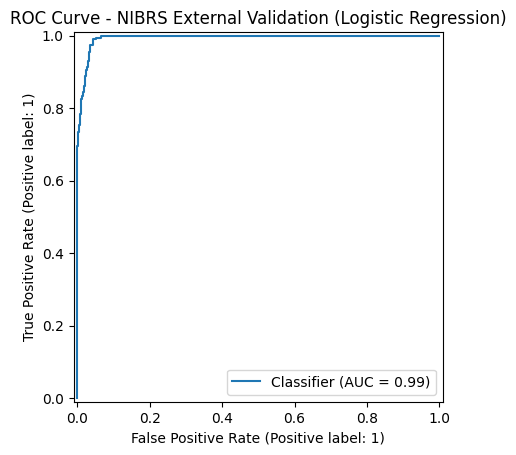

In [76]:
agency_perf_lr = evaluate_robustness_by_agency(
    nibrs_eval_clean=nibrs_eval_clean,
    y_true=y_nibrs,
    y_pred=nibrs_pred_lr,
    y_prob=nibrs_prob_lr,
    model_name="Logistic Regression"
)

=== Agency-level Robustness: Random Forest ===

Top 10 agencies by F1


C:\Users\13398\AppData\Local\Temp\ipykernel_26352\1802885967.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,agency_id,rows,positive_rate,precision,recall,f1,auc
7,2539,50.0,1.00,1.000000,1.000000,1.000000,NaN
10,2615,50.0,1.00,1.000000,1.000000,1.000000,NaN
8,2545,50.0,0.92,0.934783,0.934783,0.934783,0.902174
12,2791,50.0,0.72,0.720000,1.000000,0.837209,0.523810
13,2793,50.0,0.36,0.360000,1.000000,0.529412,0.515625
4,2477,50.0,0.00,0.000000,0.000000,0.000000,NaN
0,2320,50.0,0.00,0.000000,0.000000,0.000000,NaN
1,2388,50.0,0.00,0.000000,0.000000,0.000000,NaN
2,2400,50.0,0.00,0.000000,0.000000,0.000000,NaN
5,2500,50.0,0.00,0.000000,0.000000,0.000000,NaN



Bottom 10 agencies by F1


,agency_id,rows,positive_rate,precision,recall,f1,auc
0,2320,50.0,0.0,0.0,0.0,0.0,NaN
1,2388,50.0,0.0,0.0,0.0,0.0,NaN
2,2400,50.0,0.0,0.0,0.0,0.0,NaN
3,2421,16.0,0.0,0.0,0.0,0.0,NaN
4,2477,50.0,0.0,0.0,0.0,0.0,NaN
5,2500,50.0,0.0,0.0,0.0,0.0,NaN
6,2513,50.0,0.0,0.0,0.0,0.0,NaN
9,2586,50.0,0.0,0.0,0.0,0.0,NaN
14,2917,50.0,0.0,0.0,0.0,0.0,NaN
11,2765,50.0,0.0,0.0,0.0,0.0,NaN


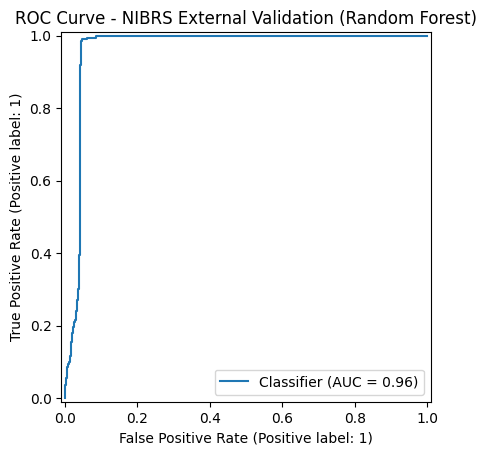

In [77]:
agency_perf_rf = evaluate_robustness_by_agency(
    nibrs_eval_clean=nibrs_eval_clean,
    y_true=y_nibrs,
    y_pred=nibrs_pred_rf,
    y_prob=nibrs_prob_rf,
    model_name="Random Forest"
)

In [78]:
# GB external validation on NIBRS
nibrs_prob_gb = gb_generic.predict_proba(X_nibrs)[:, 1]
nibrs_pred_gb = (nibrs_prob_gb >= best_threshold_generic).astype(int)

print("=== External Validation on NIBRS (Gradient Boosting) ===")
print(classification_report(y_nibrs, nibrs_pred_gb, digits=4))
print("NIBRS External AUC (GB):", roc_auc_score(y_nibrs, nibrs_prob_gb))

=== External Validation on NIBRS (Gradient Boosting) ===
              precision    recall  f1-score   support

           0     0.9979    0.9526    0.9747      1012
           1     0.8049    0.9900    0.8879       200

    accuracy                         0.9587      1212
   macro avg     0.9014    0.9713    0.9313      1212
weighted avg     0.9661    0.9587    0.9604      1212

NIBRS External AUC (GB): 0.9763537549407115


In [79]:
# external validation
nibrs_prob = gb_generic.predict_proba(X_nibrs)[:, 1]
nibrs_pred = (nibrs_prob >= best_threshold_generic).astype(int)

print("=== External Validation on NIBRS ===")
print(classification_report(y_nibrs, nibrs_pred, digits=4))
print("NIBRS External AUC:", roc_auc_score(y_nibrs, nibrs_prob))

=== External Validation on NIBRS ===
              precision    recall  f1-score   support

           0     0.9979    0.9526    0.9747      1012
           1     0.8049    0.9900    0.8879       200

    accuracy                         0.9587      1212
   macro avg     0.9014    0.9713    0.9313      1212
weighted avg     0.9661    0.9587    0.9604      1212

NIBRS External AUC: 0.9763537549407115


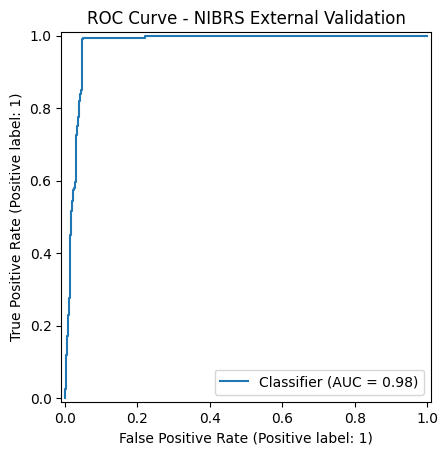

In [80]:
RocCurveDisplay.from_predictions(y_nibrs, nibrs_prob)
plt.title("ROC Curve - NIBRS External Validation")
plt.show()

In [81]:
# Time-based Cross Validation
cv_df = chicago_generic_df.copy()
cv_df = cv_df.sort_values(["week_start", "district"]).reset_index(drop=True)
cv_df = cv_df[["district", "week_start", "target_next_week"] + generic_features].copy()

print("CV dataframe shape:", cv_df.shape)
print("CV positive rate:", cv_df["target_next_week"].mean())
print("Weeks:", cv_df["week_start"].min(), "to", cv_df["week_start"].max())

unique_weeks = np.array(sorted(cv_df["week_start"].unique()))
n_folds = 5
fold_size = len(unique_weeks) // (n_folds + 1)

folds = []
for i in range(1, n_folds + 1):
    train_end = fold_size * i
    val_end = fold_size * (i + 1)

    train_weeks = unique_weeks[:train_end]
    val_weeks = unique_weeks[train_end:val_end]

    if len(val_weeks) == 0:
        continue

    folds.append((train_weeks, val_weeks))

print("Number of folds:", len(folds))
for i, (tr_w, va_w) in enumerate(folds, 1):
    print(
        f"Fold {i}: "
        f"train {tr_w[0].date()} -> {tr_w[-1].date()} | "
        f"val {va_w[0].date()} -> {va_w[-1].date()}"
    )


def run_time_cv(model, model_name, threshold, cv_df, features, folds):
    results = []

    for fold_id, (train_weeks, val_weeks) in enumerate(folds, start=1):
        train_fold = cv_df[cv_df["week_start"].isin(train_weeks)].copy()
        val_fold   = cv_df[cv_df["week_start"].isin(val_weeks)].copy()

        X_train_fold = train_fold[features]
        y_train_fold = train_fold["target_next_week"].astype(int)

        X_val_fold = val_fold[features]
        y_val_fold = val_fold["target_next_week"].astype(int)

        model.fit(X_train_fold, y_train_fold)

        val_prob = model.predict_proba(X_val_fold)[:, 1]
        val_pred = (val_prob >= threshold).astype(int)

        results.append({
            "model": model_name,
            "fold": fold_id,
            "train_rows": len(train_fold),
            "val_rows": len(val_fold),
            "train_pos_rate": y_train_fold.mean(),
            "val_pos_rate": y_val_fold.mean(),
            "precision": precision_score(y_val_fold, val_pred, zero_division=0),
            "recall": recall_score(y_val_fold, val_pred, zero_division=0),
            "f1": f1_score(y_val_fold, val_pred, zero_division=0),
            "auc": roc_auc_score(y_val_fold, val_prob)
        })

    return pd.DataFrame(results)

CV dataframe shape: (12682, 12)
CV positive rate: 0.13530988803027913
Weeks: 2015-01-12 00:00:00 to 2025-12-22 00:00:00
Number of folds: 5
Fold 1: train 2015-01-12 -> 2016-10-31 | val 2016-11-07 -> 2018-08-27
Fold 2: train 2015-01-12 -> 2018-08-27 | val 2018-09-03 -> 2020-06-22
Fold 3: train 2015-01-12 -> 2020-06-22 | val 2020-06-29 -> 2022-04-18
Fold 4: train 2015-01-12 -> 2022-04-18 | val 2022-04-25 -> 2024-02-12
Fold 5: train 2015-01-12 -> 2024-02-12 | val 2024-02-19 -> 2025-12-08


In [82]:
cv_lr = run_time_cv(
    model=Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42))
    ]),
    model_name="Logistic Regression",
    threshold=best_threshold_lr,
    cv_df=cv_df,
    features=generic_features,
    folds=folds
)

cv_rf = run_time_cv(
    model=RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_split=20,
        min_samples_leaf=8,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),
    model_name="Random Forest",
    threshold=best_threshold_rf,
    cv_df=cv_df,
    features=generic_features,
    folds=folds
)

cv_gb = run_time_cv(
    model=GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    model_name="Gradient Boosting",
    threshold=best_threshold_generic,
    cv_df=cv_df,
    features=generic_features,
    folds=folds
)

In [83]:
cv_all = pd.concat([cv_lr, cv_rf, cv_gb], axis=0, ignore_index=True)
cv_all

,model,fold,train_rows,val_rows,train_pos_rate,val_pos_rate,precision,recall,f1,auc
0,Logistic Regression,1,2111,2100,0.135007,0.135714,0.551402,0.828070,0.661992,0.942607
1,Logistic Regression,2,4211,2100,0.135360,0.135714,0.606509,0.719298,0.658106,0.921545
2,Logistic Regression,3,6311,2109,0.135478,0.135135,0.901639,0.192982,0.317919,0.951608
3,Logistic Regression,4,8420,2113,0.135392,0.134879,0.432886,0.905263,0.585698,0.927909
4,Logistic Regression,5,10533,2105,0.135289,0.135392,0.430556,0.761404,0.550063,0.906809
5,Random Forest,1,2111,2100,0.135007,0.135714,0.630499,0.754386,0.686901,0.950450
6,Random Forest,2,4211,2100,0.135360,0.135714,0.654206,0.736842,0.693069,0.920971
7,Random Forest,3,6311,2109,0.135478,0.135135,1.000000,0.154386,0.267477,0.884480
8,Random Forest,4,8420,2113,0.135392,0.134879,0.407960,0.863158,0.554054,0.913334
9,Random Forest,5,10533,2105,0.135289,0.135392,0.423954,0.782456,0.549938,0.907629


In [84]:
cv_summary_all = (
    cv_all.groupby("model")[["precision", "recall", "f1", "auc"]]
    .agg(["mean", "std"])
    .round(4)
)

cv_summary_all

precision          recall              f1             auc  \
                         mean     std    mean     std    mean     std    mean   
model                                                                           
Gradient Boosting      0.7233  0.1697  0.5179  0.2589  0.5362  0.2200  0.9194   
Logistic Regression    0.5846  0.1929  0.6814  0.2820  0.5548  0.1408  0.9301   
Random Forest          0.6233  0.2393  0.6582  0.2858  0.5503  0.1725  0.9154   

                             
                        std  
model                        
Gradient Boosting    0.0185  
Logistic Regression  0.0176  
Random Forest        0.0239

In [85]:
# Build expanding-window folds by week
unique_weeks = np.array(sorted(cv_df["week_start"].unique()))

n_folds = 5
fold_size = len(unique_weeks) // (n_folds + 1)

folds = []
for i in range(1, n_folds + 1):
    train_end = fold_size * i
    val_end = fold_size * (i + 1)

    train_weeks = unique_weeks[:train_end]
    val_weeks = unique_weeks[train_end:val_end]

    if len(val_weeks) == 0:
        continue

    folds.append((train_weeks, val_weeks))

print("Number of folds:", len(folds))
for i, (tr_w, va_w) in enumerate(folds, 1):
    print(
        f"Fold {i}: "
        f"train {tr_w[0].date()} -> {tr_w[-1].date()} | "
        f"val {va_w[0].date()} -> {va_w[-1].date()}"
    )

Number of folds: 5
Fold 1: train 2015-01-12 -> 2016-10-31 | val 2016-11-07 -> 2018-08-27
Fold 2: train 2015-01-12 -> 2018-08-27 | val 2018-09-03 -> 2020-06-22
Fold 3: train 2015-01-12 -> 2020-06-22 | val 2020-06-29 -> 2022-04-18
Fold 4: train 2015-01-12 -> 2022-04-18 | val 2022-04-25 -> 2024-02-12
Fold 5: train 2015-01-12 -> 2024-02-12 | val 2024-02-19 -> 2025-12-08


In [86]:
# Run CV
cv_results = []

for fold_id, (train_weeks, val_weeks) in enumerate(folds, start=1):
    train_fold = cv_df[cv_df["week_start"].isin(train_weeks)].copy()
    val_fold   = cv_df[cv_df["week_start"].isin(val_weeks)].copy()

    X_train_fold = train_fold[generic_features]
    y_train_fold = train_fold["target_next_week"].astype(int)

    X_val_fold = val_fold[generic_features]
    y_val_fold = val_fold["target_next_week"].astype(int)

    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X_train_fold, y_train_fold)

    val_prob = model.predict_proba(X_val_fold)[:, 1]
    val_pred = (val_prob >= best_threshold_generic).astype(int)

    fold_result = {
        "fold": fold_id,
        "train_rows": len(train_fold),
        "val_rows": len(val_fold),
        "train_pos_rate": y_train_fold.mean(),
        "val_pos_rate": y_val_fold.mean(),
        "precision": precision_score(y_val_fold, val_pred, zero_division=0),
        "recall": recall_score(y_val_fold, val_pred, zero_division=0),
        "f1": f1_score(y_val_fold, val_pred, zero_division=0),
        "auc": roc_auc_score(y_val_fold, val_prob)
    }

    cv_results.append(fold_result)

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,fold,train_rows,val_rows,train_pos_rate,val_pos_rate,precision,recall,f1,auc
0,1,2111,2100,0.135007,0.135714,0.638889,0.726316,0.679803,0.952416
1,2,4211,2100,0.135360,0.135714,0.747788,0.592982,0.661448,0.911655
2,3,6311,2109,0.135478,0.135135,1.000000,0.080702,0.149351,0.910142
3,4,8420,2113,0.135392,0.134879,0.553977,0.684211,0.612245,0.911222
4,5,10533,2105,0.135289,0.135392,0.676056,0.505263,0.578313,0.911689


In [87]:
# CV summary
cv_summary = pd.DataFrame({
    "metric": ["precision", "recall", "f1", "auc"],
    "mean": [
        cv_results_df["precision"].mean(),
        cv_results_df["recall"].mean(),
        cv_results_df["f1"].mean(),
        cv_results_df["auc"].mean()
    ],
    "std": [
        cv_results_df["precision"].std(),
        cv_results_df["recall"].std(),
        cv_results_df["f1"].std(),
        cv_results_df["auc"].std()
    ]
})

print("=== Time-based Cross Validation Results (Chicago aligned model) ===")
display(cv_results_df)
display(cv_summary)

=== Time-based Cross Validation Results (Chicago aligned model) ===


,fold,train_rows,val_rows,train_pos_rate,val_pos_rate,precision,recall,f1,auc
0,1,2111,2100,0.135007,0.135714,0.638889,0.726316,0.679803,0.952416
1,2,4211,2100,0.135360,0.135714,0.747788,0.592982,0.661448,0.911655
2,3,6311,2109,0.135478,0.135135,1.000000,0.080702,0.149351,0.910142
3,4,8420,2113,0.135392,0.134879,0.553977,0.684211,0.612245,0.911222
4,5,10533,2105,0.135289,0.135392,0.676056,0.505263,0.578313,0.911689


,metric,mean,std
0,precision,0.723342,0.169698
1,recall,0.517895,0.258861
2,f1,0.536232,0.219953
3,auc,0.919425,0.018453


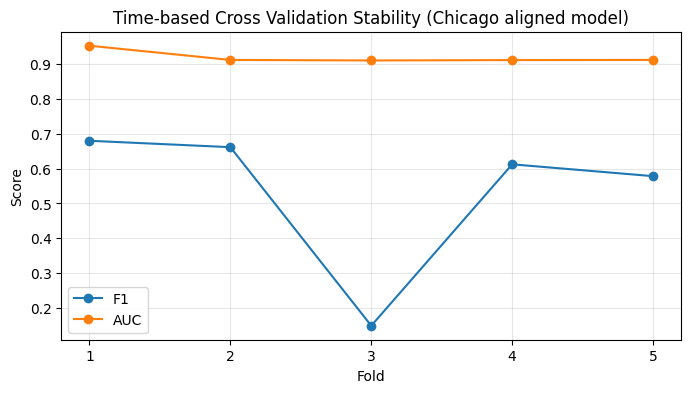

In [88]:
# Plot CV stability
plt.figure(figsize=(8, 4))
plt.plot(cv_results_df["fold"], cv_results_df["f1"], marker="o", label="F1")
plt.plot(cv_results_df["fold"], cv_results_df["auc"], marker="o", label="AUC")
plt.xlabel("Fold")
plt.ylabel("Score")
plt.title("Time-based Cross Validation Stability (Chicago aligned model)")
plt.xticks(cv_results_df["fold"])
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [89]:
for fold_id, (train_weeks, val_weeks) in enumerate(folds, start=1):
    train_fold = cv_df[cv_df["week_start"].isin(train_weeks)].copy()
    val_fold   = cv_df[cv_df["week_start"].isin(val_weeks)].copy()

    X_train_fold = train_fold[generic_features]
    y_train_fold = train_fold["target_next_week"].astype(int)

    X_val_fold = val_fold[generic_features]
    y_val_fold = val_fold["target_next_week"].astype(int)

    model = GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
    model.fit(X_train_fold, y_train_fold)

    val_prob = model.predict_proba(X_val_fold)[:, 1]
    val_pred = (val_prob >= best_threshold_generic).astype(int)

    print(f"\nFold {fold_id}")
    print("Actual positives:", y_val_fold.sum())
    print("Predicted positives:", val_pred.sum())
    print("Prob min/max:", val_prob.min(), val_prob.max())
    print("Prob quantiles:", np.quantile(val_prob, [0.5, 0.75, 0.9, 0.95, 0.99]))


Fold 1
Actual positives: 285
Predicted positives: 324
Prob min/max: 0.002291666614474164 0.9962741959241393
Prob quantiles: [0.00612524 0.07149796 0.68424173 0.88272701 0.97067538]

Fold 2
Actual positives: 285
Predicted positives: 226
Prob min/max: 0.0015442054954055535 0.9935499611787842
Prob quantiles: [0.00389172 0.03258928 0.43158414 0.73287368 0.97882733]

Fold 3
Actual positives: 285
Predicted positives: 23
Prob min/max: 0.0025981815085389676 0.9585996535201508
Prob quantiles: [0.00796082 0.01243464 0.02485381 0.0621389  0.41564288]

Fold 4
Actual positives: 285
Predicted positives: 352
Prob min/max: 0.0028708934300068177 0.9513206338447648
Prob quantiles: [0.05118942 0.23622335 0.58184257 0.75423086 0.89187626]

Fold 5
Actual positives: 285
Predicted positives: 213
Prob min/max: 0.0025871883626513155 0.924763708515921
Prob quantiles: [0.03275894 0.16093745 0.40165609 0.6207292  0.84424786]


In [90]:
# fold3 why??
fold_id_to_check = 3
train_weeks, val_weeks = folds[fold_id_to_check - 1]

train_fold = cv_df[cv_df["week_start"].isin(train_weeks)].copy()
val_fold   = cv_df[cv_df["week_start"].isin(val_weeks)].copy()

X_train_fold = train_fold[generic_features]
y_train_fold = train_fold["target_next_week"].astype(int)

X_val_fold = val_fold[generic_features]
y_val_fold = val_fold["target_next_week"].astype(int)

model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
model.fit(X_train_fold, y_train_fold)

val_prob = model.predict_proba(X_val_fold)[:, 1]

threshold_table = []
for th in np.arange(0.10, 0.55, 0.05):
    pred = (val_prob >= th).astype(int)
    threshold_table.append({
        "threshold": round(th, 2),
        "predicted_positive": pred.sum(),
        "precision": precision_score(y_val_fold, pred, zero_division=0),
        "recall": recall_score(y_val_fold, pred, zero_division=0),
        "f1": f1_score(y_val_fold, pred, zero_division=0)
    })

pd.DataFrame(threshold_table)

,threshold,predicted_positive,precision,recall,f1
0,0.10,71,0.915493,0.228070,0.365169
1,0.15,52,0.884615,0.161404,0.272997
2,0.20,40,0.925000,0.129825,0.227692
3,0.25,38,0.947368,0.126316,0.222910
4,0.30,33,0.969697,0.112281,0.201258
5,0.35,26,0.961538,0.087719,0.160772
6,0.40,23,1.000000,0.080702,0.149351
7,0.45,20,1.000000,0.070175,0.131148
8,0.50,15,1.000000,0.052632,0.100000


AI declaration: A small portion of the code was completed with the assistance of AI, and AI was also used for debugging.